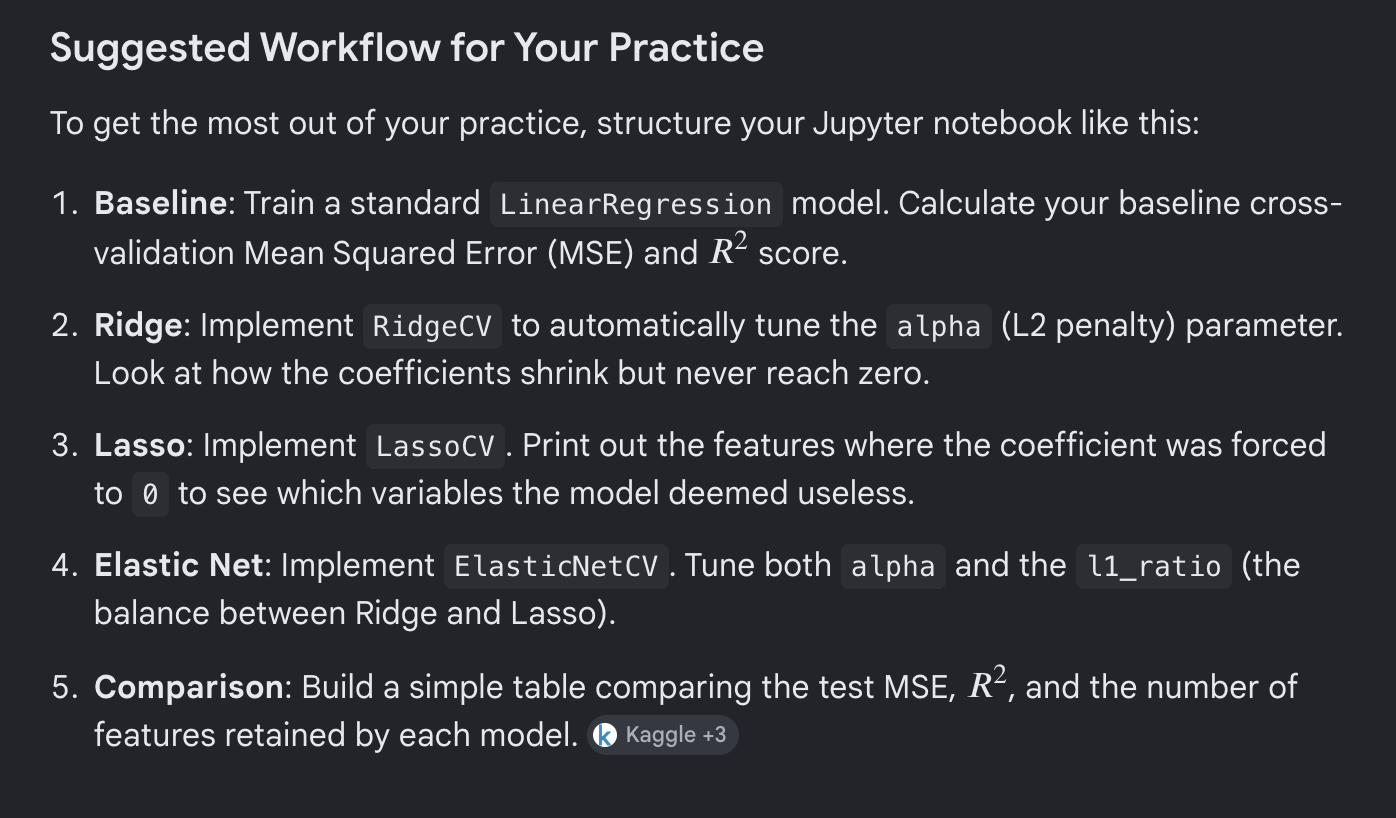

# <font color='blue'> Baseline Linear Regression </font>

## <font color='orange'> Loading Data </font>

In [20]:
# loading data
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_csv('../data/used_cars.xls')

# Display the first few rows
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## <font color='orange'> Using K-Fold Data Splitting </font>

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression # Or any other regressor like RandomForestRegressor

# Step 1: Separate target (y) and features (X)
y = df['selling_price']

# # Step 2: One-hot encode categorical variables (fuel, transmission, seller_type)
# ONLY drop the columns you want to ignore completely (like 'name' and 'owner')
# Specify columns= to make sure pandas looks at your column names
X = df.drop(columns=['selling_price', 'owner'])

# Step 2: One-hot encode the categorical variables that are still inside X
X_encoded = pd.get_dummies(X, columns=['name', 'fuel', 'transmission', 'seller_type'], drop_first=True)

# Step 3: Initialize the K-Fold validator (e.g., 5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Initialize your Machine Learning model
model = LinearRegression()

# Step 5: Evaluate using cross_val_score
# We use negative root mean squared error; then convert it to positive
scores = cross_val_score(model, X_encoded, y, cv=kf, scoring='neg_root_mean_squared_error')
rmse_scores = -scores

# Calculate R2 scores for each fold
r2_scores = cross_val_score(model, X_encoded, y, cv=kf, scoring="r2")

# Step 6: Print performance summary
print(f"RMSE scores for each fold: {rmse_scores}")
print(f"Average RMSE: {np.mean(rmse_scores):.2f} (+/- {np.std(rmse_scores):.2f})")

# Print the R2 results
print(f"R² scores for each fold: {r2_scores}")
print(f"Average R² score: {np.mean(r2_scores):.3f} (+/- {np.std(r2_scores):.3f})")

RMSE scores for each fold: [396150.98607679 334604.34417176 391241.61245357 399553.17683952
 406346.35406045]
Average RMSE: 385579.29 (+/- 25956.92)
R² scores for each fold: [0.48574415 0.64234859 0.54853025 0.53469789 0.55676206]
Average R² score: 0.554 (+/- 0.051)


## <font color='orange'> Using Test-Train Split </font>

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# Step 1: Separate target (y) and features (X)
y = df['selling_price']
X = df.drop(columns=['selling_price', 'name', 'owner'])

# Step 2: One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=['fuel', 'transmission', 'seller_type'], drop_first=True)

# Step 3: Split into training and testing sets (e.g., 80% train, 20% test)
# random_state ensures you get the exact same split every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Step 4: Initialize and train your model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Make predictions on the unseen test data
predictions = model.predict(X_test)

# Step 6: Evaluate the performance
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")


Test RMSE: 427613.87
Test R² Score: 0.40


### <font color='blue'> The K-Fold method clearly performs better than a simple Test-Train Split. </font>

## <font color='orange'> Ridge Regression (Using Test-Train Split) </font>

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

# set target and feature columns
y = df['selling_price']
X = df.drop(columns=['selling_price', 'name', 'owner'])

# scale the features so that the ridge penaly affects them equally
# this is really important for Ridge, Lasso and ElasticNet methods
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split into train-test datasets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# initialise the ridge method
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_basic = ridge.predict(X_test)

print("MSE (alpha = 1.0):", mean_squared_error(y_test, pred_basic))
print("Coefficients (alpha = 1.0):", ridge.coef_)

param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 500]}
grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring="neg_mean_squared_error")

grid.fit(X_train, y_train)
best_ridge = grid.best_estimator_
pred_best = best_ridge.predict(X_test)

print("Best alpha selected:", grid.best_params_["alpha"])
print("MSE (best alpha):", mean_squared_error(y_test, pred_best))
print("Coefficients (best alpha):", best_ridge.coef_)

ValueError: could not convert string to float: 'Petrol'